<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        30 Points
    </font>
</div>


In [1]:
FULLNAME = 'mohammadreza koohi'
STD_ID = '402207199'

# Q3. License Plate Detection and Recognition (30 points)

## Introduction

In this assignment, we will build a two-stage license plate recognition system:

1. First stage: Detect license plates in an image (license plate detection / LPD)
2. Second stage: Recognize characters within the detected license plate (license plate recognition / LPR)

This approach is not explicitly an OCR (Optical Character Recognition), but it has some similarities with important differences. Unlike general OCR which often relies on sequence models (like RNNs or Transformers) to capture language context, license plates have a fixed format with predictable structure. This allows us to use multi-class classification or object detection models for it - first to locate plates, then to locate and classify individual characters.

## Background on YOLO (You Only Look Once)

### Evolution of Object Detection

Object detection has evolved significantly over the years:
- **Two-stage detectors** (like R-CNN family): First propose regions, then classify them
- **Single-stage detectors** (like YOLO and SSD): Predict bounding boxes and classes in a single forward pass

YOLO revolutionized object detection by framing it as a regression problem rather than a classification problem. Instead of generating region proposals and then classifying each region (a slow, two-stage process), YOLO divides the image into a grid and predicts bounding boxes and class probabilities directly in a single forward pass.

### YOLO Architecture

![YOLO Architecture](https://velog.velcdn.com/images/hunniee_j/post/cbd3888c-8b75-4325-988f-eadaded84232/image.JPG)

The basic YOLO approach:

1. **Grid Division**: Divide the image into an S×S grid
2. **Bounding Box Prediction**: Each grid cell predicts B bounding boxes, each with 5 parameters (x, y, w, h, confidence)
3. **Class Prediction**: Each grid cell also predicts class probabilities
4. **Non-Maximum Suppression**: Remove overlapping boxes with lower confidence scores

for a brief explanation of Object detection from RCNN to yolo version8 visit this [link](https://youtube.com/playlist?list=PL8VDJoEXIjppNvOzocFbRciZBrtSMi81v&si=qIh3VagQOzgWZ7Go)

the latest version of yolo is YOLO 12 and [here](https://docs.ultralytics.com/models/yolo12/) is Ultralytics documentation about it (all models of yolo family available in ultralytics has accessible documentation  [here](https://docs.ultralytics.com/models/) too.)


## Ultralytics Framework

Ultralytics is a Python library that makes it easy to train, test, and deploy YOLO models. Key features:

- **Easy to use API**: Simple Python API for training, validation, and inference
- **Pre-trained models**: Various pre-trained models of different sizes (nano to extra large)
- **Export options**: Export to various formats (ONNX, TFLite, CoreML, etc.)
- **Multi-task learning**: Support for object detection, segmentation, and pose estimation



## Assignment Tasks

In this assignment, you will:

1. Train a YOLO model for license plate detection on LPD dataset
2. Train a CNN model for license plate recognition within LPR license plates (7 digit + 1 letter classificaiton task)
3. Create an end-to-end pipeline that connects step 1 with 2
4. Evaluate the performance of your system on the test data


The dataset are available in [this](https://drive.google.com/drive/folders/1StRhbI28MaoiuXqA2rG5vGqKG5K2bMW6?usp=sharing) drive folder. let's dive into it!



In [2]:
#Necessary installations

%pip install -q ultralytics
%pip install -q matplotlib opencv-python pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 973.0/973.0 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.3 MB/s eta 0:00:00


In [3]:
#imports

import os
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random
import pandas as pd
import pandas as pd
from PIL import Image
import torch
from torchvision import transforms
from IPython.display import display
import pandas as pd
import torch.utils.data as data
import torch
from tqdm import tqdm
import torch.optim as optim
import torch
import torch.nn as nn
from torchvision import models
import cv2


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
BASE_PATH = '/content'

### 1. LPD - YOLO

In [6]:
LPD_RELATIVE_PATH = 'LPD'
LPD_DIR = f'{BASE_PATH}/{LPD_RELATIVE_PATH}'

images_dir = os.path.join(LPD_DIR, 'images')
labels_dir = os.path.join(LPD_DIR, 'labels')

In [7]:
# my

!pip install -q gdown


In [8]:
import gdown

lpr_id = "14p3KgYNCyL1kE5Vyq0j9KjfJ9CPeDgJ3"
lpd_id = "1tSza68O5AT4DK52UOiL6DZrnWENfourA"

gdown.download(f"https://drive.google.com/uc?id={lpr_id}", output="LPR.zip", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={lpd_id}", output="LPD.zip", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=14p3KgYNCyL1kE5Vyq0j9KjfJ9CPeDgJ3
From (redirected): https://drive.google.com/uc?id=14p3KgYNCyL1kE5Vyq0j9KjfJ9CPeDgJ3&confirm=t&uuid=0a3c7899-b9d8-4ef4-8a08-ed2853a62fbf
To: /content/LPR.zip
100%|██████████| 256M/256M [00:06<00:00, 38.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1tSza68O5AT4DK52UOiL6DZrnWENfourA
From (redirected): https://drive.google.com/uc?id=1tSza68O5AT4DK52UOiL6DZrnWENfourA&confirm=t&uuid=91600a27-403d-43c6-9b97-e2a77a0de6fa
To: /content/LPD.zip
100%|██████████| 3.76G/3.76G [00:53<00:00, 69.9MB/s]


'LPD.zip'

In [9]:
import zipfile

with zipfile.ZipFile("LPR.zip", 'r') as zip_ref:
    zip_ref.extractall("LPR")

with zipfile.ZipFile("LPD.zip", 'r') as zip_ref:
    zip_ref.extractall("LPD")


In [10]:
#end

In [11]:
image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]

print(f"Dataset contains {len(image_files)} images and {len(label_files)} labels")


objects_count = 0
for label_file in [os.path.join(labels_dir, f) for f in label_files]:
    with open(label_file, 'r') as f:
        objects_count += len(f.readlines())

print(f"Total license plates in dataset: {objects_count}")
print(f"Average plates per image: {objects_count / max(1, len(image_files)):.2f}")

Dataset contains 6252 images and 6252 labels
Total license plates in dataset: 7257
Average plates per image: 1.16


<font color="orange">
1. What is the structure of YOLO's label files (`.txt`), and why are bounding box coordinates normalized?  
<br>2. How does the YAML configuration file in YOLO define a dataset, and what role does the `nc` (number of classes) parameter play?  
<br>3. Why does YOLO use a grid system for predictions, and how does it handle multiple objects in a single grid cell?  
</font>


In [12]:
# you must create a yaml file there is just one class object detection and you must split the dataset into two parts (80%-20% for train and val)
# the executed result of cell is belong to train = val = all data for better understanding about the YOLO results.
base_path = '/content/LPD'
images_path = os.path.join(base_path, 'images')
labels_path = os.path.join(base_path, 'labels')

train_images = os.path.join(base_path, 'LPD_YOLO/images/train')
val_images = os.path.join(base_path, 'LPD_YOLO/images/val')
train_labels = os.path.join(base_path, 'LPD_YOLO/labels/train')
val_labels = os.path.join(base_path, 'LPD_YOLO/labels/val')

for d in [train_images, val_images, train_labels, val_labels]:
    os.makedirs(d, exist_ok=True)

image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(image_files)

split_idx = int(0.8 * len(image_files))
train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

def move_data(files, target_img_dir, target_lbl_dir):
    for f in files:
        img_src = os.path.join(images_path, f)
        lbl_src = os.path.join(labels_path, f.replace('.jpg', '.txt').replace('.png', '.txt'))

        shutil.copy(img_src, os.path.join(target_img_dir, f))
        shutil.copy(lbl_src, os.path.join(target_lbl_dir, os.path.basename(lbl_src)))

move_data(train_files, train_images, train_labels)
move_data(val_files, val_images, val_labels)

# YAML
yaml_content = """
train: /content/LPD/LPD_YOLO/images/train
val: /content/LPD/LPD_YOLO/images/val

nc: 1
names: ['plate']
"""


with open(os.path.join(base_path, 'data.yaml'), 'w') as f:
    f.write(yaml_content)

print("Dataset successfully split and YAML file created!")

YAML_PATH =  os.path.join(LPD_DIR, 'data.yaml')

Dataset successfully split and YAML file created!


In [13]:
VERSION = '8'
MODEL_SIZE = 's'  # Options: n, s, m, l, x
EPOCHS = 20
IMGSZ = 640
BATCH = 16
DEVICE = '0'

<font color="orange">
Compare the architectural and functional advancements in YOLO versions 8 through 12. Specifically:  

1. **YOLOv8**:  
   - What was the motivation behind adopting an anchor-free design, and how did this impact training complexity and performance?  
   - How did the integration of CSPDarknet and PANet improve feature extraction and multi-scale detection compared to earlier versions?  

2. **YOLOv9 (Hypothetical/Unofficial)**:  
   - If YOLOv9 introduced dynamic label assignment, how does this differ from static assignment in YOLOv8, and what are the implications for model accuracy and convergence speed?  
   - What role might lightweight model variants (e.g., YOLOv9n) play in edge-device deployment, and how were they optimized for resource-constrained environments?  

3. **YOLOv10**:  
   - How did hybrid loss functions (e.g., combining CIoU and focal loss) enhance the training process, and what challenges in object detection were they designed to address?  
   - What advancements in model pruning and quantization were introduced, and how did these techniques reduce model size without compromising accuracy?  

4. **YOLOv11**:  
   - In what ways did self-calibrated convolutions improve feature extraction, and how do they compare to traditional convolutional layers in terms of computational efficiency and accuracy?  
   - How did the introduction of multi-task learning (e.g., joint object detection and segmentation) expand the capabilities of YOLOv11, and what new applications does this enable?  

5. **YOLOv12**:  
   - What benefits does the integration of transformer-based modules bring to YOLOv12, and how does this hybrid architecture balance the strengths of CNNs and transformers?  
   - How does uncertainty estimation in YOLOv12 improve the reliability of predictions, particularly in safety-critical applications like autonomous driving or medical imaging?  
   - Discuss the role of domain adaptation techniques in YOLOv12 and how they address challenges like dataset bias or environmental variability.  

Based on these advancements, which version would you recommend for this aplication, and why?  
</font>

In [14]:
LPD_model = 'yolov8n.pt'

In [ ]:
print(f"Starting YOLO{VERSION}{MODEL_SIZE} training for {EPOCHS} epochs...")

model_name = f"yolov{VERSION}{MODEL_SIZE}.pt"
model = LPD_model


model_name = f"yolov{VERSION}{MODEL_SIZE}.pt"
model = YOLO(model_name)

model.train(
    data="/content/LPD/data.yaml",
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=device,
    project="model",
    name="LPD",
    exist_ok=True
)

print("Training complete! Model saved to model/LPD folder.")

Starting YOLO8s training for 20 epochs...


100%|██████████| 21.5M/21.5M [00:00<00:00, 336MB/s]


engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/LPD/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=model, name=LPD, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript, keras=False, optimize=False, int8=False, dynamic=False, simplif

100%|██████████| 755k/755k [00:00<00:00, 153MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

...

      20/20      5.71G     0.7364     0.3926     0.8884         10        640: 100%|██████████| 313/313 [02:07<00:00,  2.46it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 40/40 [00:19<00:00,  2.04it/s]

                   all       1251       1484      0.935      0.946      0.979      0.772



20 epochs completed in 0.835 hours.
Optimizer stripped from model/LPD/weights/last.pt, 22.5MB
Optimizer stripped from model/LPD/weights/best.pt, 22.5MB

Validating model/LPD/weights/best.pt...
Ultralytics 8.3.105 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 40/40 [00:19<00:00,  2.01it/s]


                   all       1251       1484      0.935      0.946      0.979      0.772
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to model/LPD
Training complete! Model saved to model/LPD folder.


Testing model on sample images...

0: 640x640 1 plate, 10.0ms
Speed: 1.9ms preprocess, 10.0ms inference, 18.4ms postprocess per image at shape (1, 3, 640, 640)


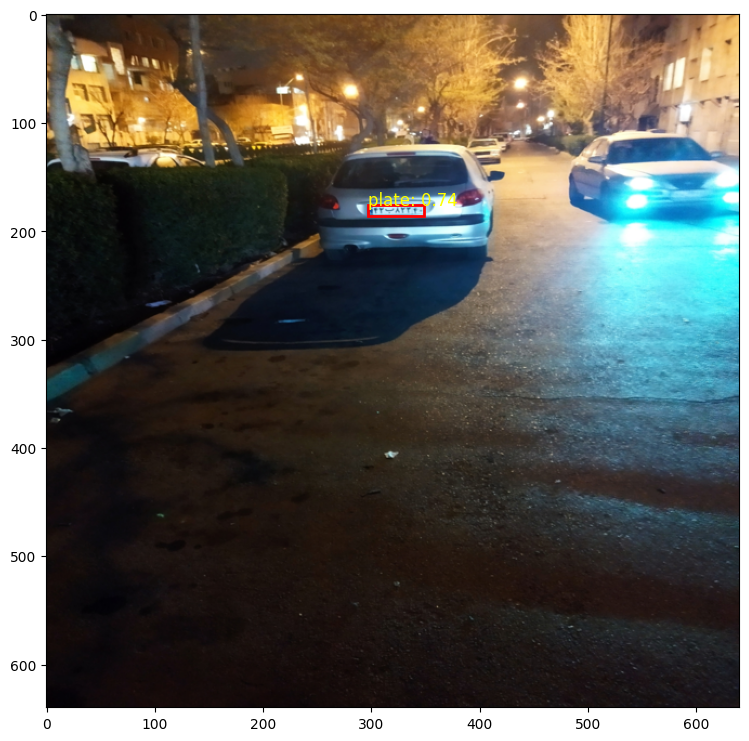


0: 640x640 1 plate, 10.4ms
Speed: 1.3ms preprocess, 10.4ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 640)


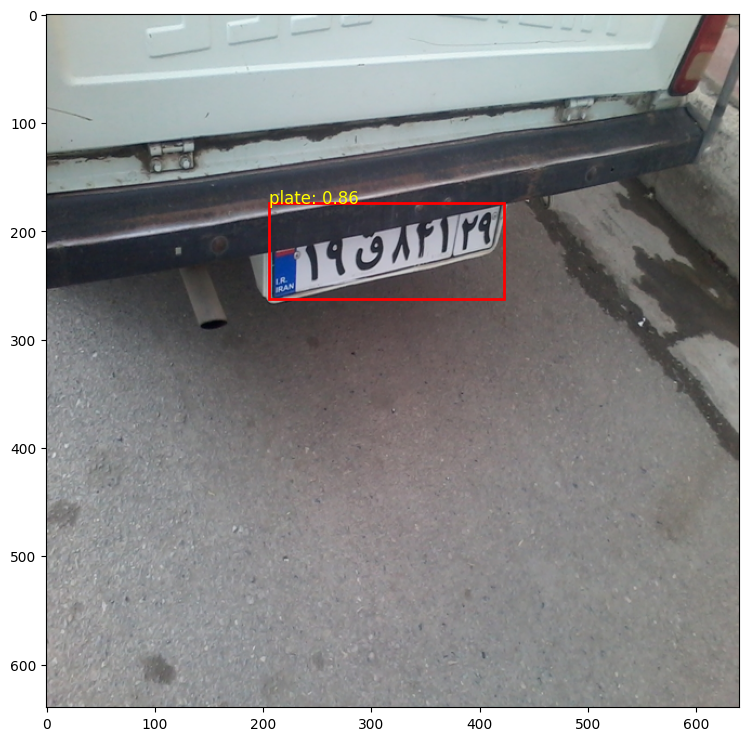


0: 640x640 1 plate, 16.4ms
Speed: 1.2ms preprocess, 16.4ms inference, 6.8ms postprocess per image at shape (1, 3, 640, 640)


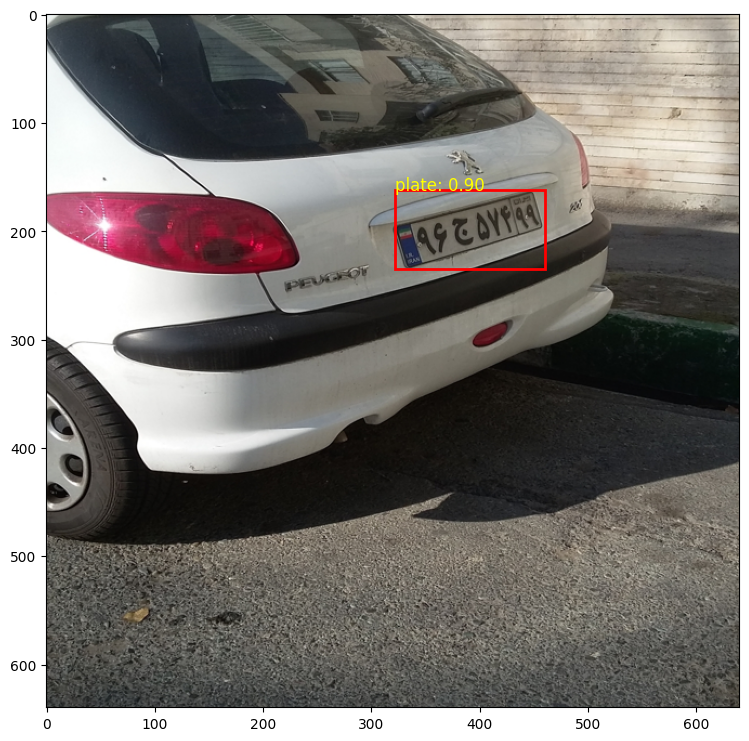


0: 640x640 1 plate, 16.4ms
Speed: 1.4ms preprocess, 16.4ms inference, 7.5ms postprocess per image at shape (1, 3, 640, 640)


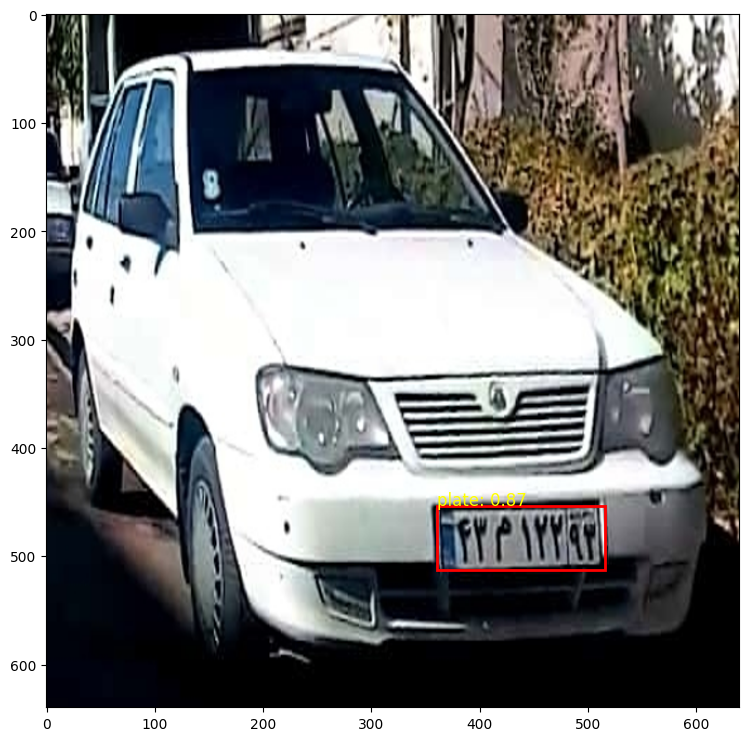


0: 640x640 3 plates, 16.4ms
Speed: 1.3ms preprocess, 16.4ms inference, 6.8ms postprocess per image at shape (1, 3, 640, 640)


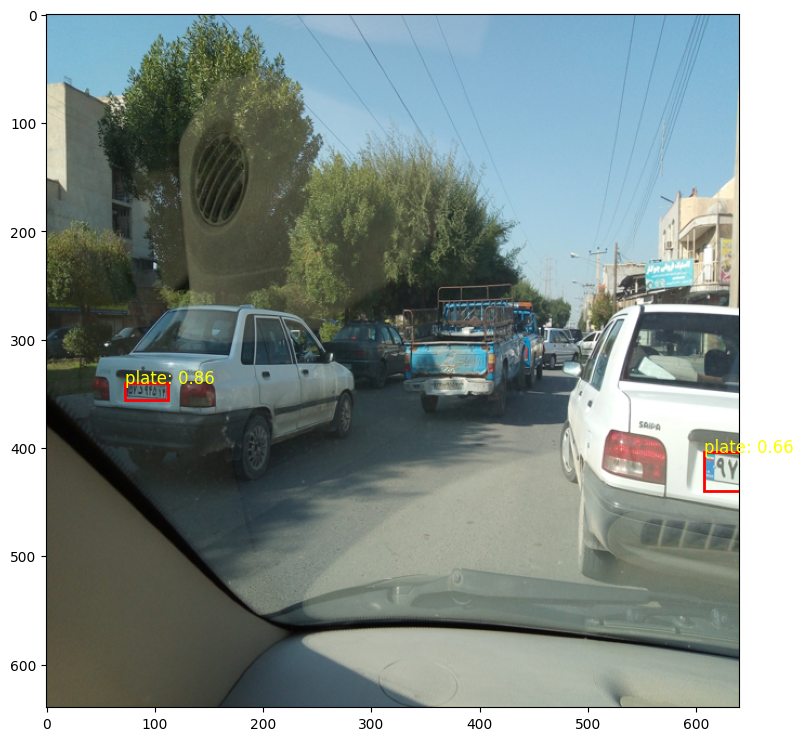

In [ ]:
model.eval()

print("Testing model on sample images...")
for img_file in random.sample(image_files, 5):
    img_path = os.path.join(images_dir, img_file)

    img = Image.open(img_path).convert("RGB")

    img_resized = img.resize((640, 640))

    img_tensor = transforms.ToTensor()(img_resized).unsqueeze(0)

    with torch.no_grad():
        outputs = model(img_tensor)

    result = outputs[0]
    boxes = result.boxes.xyxy.cpu().numpy()
    labels = result.boxes.cls.cpu().numpy().astype(int)
    scores = result.boxes.conf.cpu().numpy()

    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(np.array(img_resized))
    for box, label, score in zip(boxes, labels, scores):
        if score > 0.5:
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1, f'{result.names[label]}: {score:.2f}', color='yellow', fontsize=12)

    plt.show()


### 2. LPR - CNN

In [15]:
LPR_RELATIVE_PATH = 'LPR'

df = pd.read_csv(f'{BASE_PATH}/{LPR_RELATIVE_PATH}/valid_samples.csv')
df = df.sample(n=22000, random_state=42)

In [56]:
digit_vocabulary = "0123456789"
persian_letters = "آ ب پ ت ث ج چ ح خ د ذ ر ز ژ س ش ص ض ط ظ ع غ ف ق ک گ ل م ن و ه ی".split()


digit_to_idx = {char: idx for idx, char in enumerate(digit_vocabulary)}
letter_to_idx = {char: idx for idx, char in enumerate(persian_letters)}
idx_to_digit = {idx: char for idx, char in enumerate(digit_vocabulary)}
idx_to_letter = {idx: char for idx, char in enumerate(persian_letters)}


persian_to_english_digits = {
    '۰': '0', '۱': '1', '۲': '2', '۳': '3', '۴': '4',
    '۵': '5', '۶': '6', '۷': '7', '۸': '8', '۹': '9'
}

persian_letter_normalization = {
    "الف": "آ",
    "ا" : "آ",
    "ژ (معلولین و جانبازان)": "ژ",
    "ه‍" : "ه"
}



def translate(label):

    first_two_digits = ''.join([persian_to_english_digits.get(char, char) for char in label[:2]])
    persian_letter = label[2]
    remaining_digits = ''.join([persian_to_english_digits.get(char, char) for char in label[3:]])
    return first_two_digits + persian_letter + remaining_digits


def preprocess_sample(image_path, label , full_transform=True, log=False, dir_path=BASE_PATH, relative_path=f'{LPR_RELATIVE_PATH}/detections', language='en'):

    if language == 'fa':
        label = translate(label)
    elif language != 'en':
        raise Exception('Un-supported language!')

    path = f'{dir_path}/{relative_path}'

    train_transform = transforms.Compose([
        transforms.Resize((64, 128)),
        transforms.ToTensor()
    ])

    test_transform = transforms.Compose([
        transforms.Resize((64, 128)),
        transforms.ToTensor(),
    ])

    transform = train_transform if full_transform else test_transform
    image = Image.open(f'{path}/{image_path}').convert("RGB")
    image = transform(image)

    for key, value in persian_letter_normalization.items():
        label = label.replace(key, value)

    if log:
        print(label)
        for i, c in enumerate(label):
            if c in persian_letters:
                c = '*'
            print(f"{i}:{c}", end=' | ')
        print()

    digits = [digit_to_idx[char] for char in label if char.isdigit()]
    letter = letter_to_idx[label[2]]

    return image, digits, letter





    transform = train_transform if full_transform else test_transform
    image = Image.open(f'{path}/{image_path}').convert("RGB")
    image = transform(image)


    for key, value in persian_letter_normalization.items():
        label = label.replace(key, value)



    if log:
      print(label)

      for i , c in enumerate(label):
        if c in persian_letters:
          c = '*'
        print(f"{i}:{c}", end=' | ')

      print()


    digits = [digit_to_idx[char] for char in label if char.isdigit()]
    letter = letter_to_idx[label[2]]

    return image, digits, letter

In [57]:
class PLPRDataset(data.Dataset):
    def __init__(self, df , split='train',dir_path=BASE_PATH,relative_path = f'{LPR_RELATIVE_PATH}/detections', language='en'):
        self.df = df
        self.full_transform = True if split == 'train' else False
        self.dir_path = dir_path
        self.relative_path = relative_path
        self.language = language

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        label = row['label']

        image, digits, letter = preprocess_sample(
            image_path=image_path,
            label=label,
            full_transform=self.full_transform,
            dir_path=self.dir_path,
            relative_path=self.relative_path,
            language=self.language
        )

        digits_tensor = torch.tensor(digits, dtype=torch.long)
        letter_tensor = torch.tensor(letter, dtype=torch.long)

        return image, digits_tensor, letter_tensor



In [18]:
class FCNPLPRModel(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0"):
        super(FCNPLPRModel, self).__init__()

        backbone = models.__dict__[backbone_name](pretrained=True)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-2])

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        backbone_output_dim = 1280

        self.digit_head = nn.Linear(backbone_output_dim, 7 * 10)

        self.letter_head = nn.Linear(backbone_output_dim, len(persian_letters))

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        digit_logits = self.digit_head(x)
        digit_outputs = digit_logits.view(-1, 7, 10)

        letter_output = self.letter_head(x)

        return digit_outputs, letter_output


In [19]:
learning_rate = 4e-4
batch_size = 32

In [20]:
dataset = PLPRDataset(df)
dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        # persistent_workers=True
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [21]:
LPR_model = FCNPLPRModel().to(device)
digit_criterion = nn.CrossEntropyLoss()
letter_criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


In [22]:
optimizer = optim.AdamW(LPR_model.parameters(), lr=learning_rate)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    threshold=0.05,
    threshold_mode='rel',
    verbose=True
)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [23]:
def decode_predictions(digit_outputs, letter_output):
    digit_predictions = torch.argmax(digit_outputs, dim=2)
    batch_size = digit_predictions.size(0)

    digits = []
    for b in range(batch_size):
        sample_digits = []
        for i in range(7):
            try:
                sample_digits.append(idx_to_digit[digit_predictions[b][i].item()])
            except KeyError as e:
                print(f"KeyError: {e} (digit_predictions[{b}][{i}] = {digit_predictions[b][i].item()})")
                sample_digits.append("?")
        digits.append(sample_digits)

    letter_prediction = torch.argmax(letter_output, dim=1)
    letters = []
    for b in range(batch_size):
        try:
            letters.append(idx_to_letter[letter_prediction[b].item()])
        except KeyError as e:
            print(f"KeyError: {e} (letter_prediction[{b}] = {letter_prediction[b].item()})")
            letters.append("?")

    labels = []
    for b in range(batch_size):
        label = "".join(digits[b][:2]) + letters[b] + "".join(digits[b][2:])
        labels.append(label)

    return labels



def evaluate_misclassification(gt, pred):
    assert len(gt) == len(pred), "GT and Pred must have the same length."


    misclassified = []
    char_error_count = 0

    for i, (gt_char, pred_char) in enumerate(zip(gt, pred)):
        if gt_char != pred_char:
            misclassified.append(f"{gt_char} with {pred_char} at pos {i}")
            char_error_count += 1


    misclassified_str = " , ".join(misclassified) if misclassified else "None"
    result = (f"GT: {gt} | Pred: {pred} | "
              f"Misclassified: {misclassified_str} | "
              f"Char error count: {char_error_count}")

    return result , char_error_count





def calculate_accuracy(model, df, device, dir_path=BASE_PATH, relative_path=f'{LPR_RELATIVE_PATH}/detections', language='en', log=False , cer = False):
    model.eval()
    FP= []
    CE = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df)):
            image_path = row["image_path"]
            label = row["label"]
            try:
                image, true_digits, true_letter = preprocess_sample(image_path, label, full_transform=False, dir_path=dir_path, relative_path=relative_path, language=language)

            except Exception as e:
                print(f"Error processing {image_path}: {e}")
                continue
            true_label = "".join([digit_vocabulary[d] for d in true_digits[:2]]) \
                         + persian_letters[true_letter] \
                         + "".join([digit_vocabulary[d] for d in true_digits[2:]])
            image = image.unsqueeze(0).to(device)
            digit_outputs, letter_output = model(image)

            predicted_labels = decode_predictions(digit_outputs, letter_output)

            if predicted_labels[0] == true_label:
                correct += 1
            elif log:
                report , char_error_count = evaluate_misclassification(true_label,predicted_labels[0])
                CE += char_error_count
                FP.append(report)
            total += 1


    accuracy = correct / total * 100

    if cer:
        print(f'CER: {100* CE/(8*df.shape[0]): .4f}%')

    if log:
         for false_positive in FP:
            print(false_positive)



    return accuracy

In [24]:
full_df = pd.read_csv(f'{BASE_PATH}/LPR/valid_samples.csv')
test_df = full_df.loc[~full_df.index.isin(df.index)]


In [ ]:
best_accuracy = 85.0
optimal_weights = None
num_epochs = 10


for epoch in range(num_epochs):
    LPR_model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for images, digit_targets, letter_targets in progress_bar:
        images = images.to(device)
        digit_targets = digit_targets.to(device)
        letter_targets = letter_targets.to(device)

        digit_outputs, letter_output = LPR_model(images)

        digit_loss = 0
        for i in range(7):
            digit_loss += digit_criterion(digit_outputs[:, i, :], digit_targets[:, i])
        letter_loss = letter_criterion(letter_output, letter_targets)
        loss = digit_loss + letter_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

    LPR_model.eval()
    accuracy = calculate_accuracy(
        LPR_model,
        test_df,
        device,
        relative_path= f'{LPR_RELATIVE_PATH}/detections',
        language='en'
    )
    print(f"Accuracy after Epoch {epoch+1}: {accuracy:.2f}%")

    scheduler.step(accuracy)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        optimal_weights = LPR_model.state_dict()  # Save the current model weights
        print(f"New best accuracy: {best_accuracy:.2f}%. Saving model weights.")
        torch.save(LPR_model.state_dict(), f'{BASE_PATH}/model/PLPR-CNN.pth')

if optimal_weights is not None:
    LPR_model.load_state_dict(optimal_weights)
    print("Loaded optimal weights into the model.")

Epoch 1/10:   0%|          | 0/688 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/10, Average Loss: 10.2259


100%|██████████| 2561/2561 [00:32<00:00, 77.73it/s]


Accuracy after Epoch 1: 55.84%


Epoch 2/10, Average Loss: 1.8210


...

100%|██████████| 2561/2561 [00:33<00:00, 77.23it/s]


Accuracy after Epoch 9: 89.81%


Epoch 10/10, Average Loss: 0.0992


100%|██████████| 2561/2561 [00:34<00:00, 75.25it/s]

Accuracy after Epoch 10: 89.96%
Loaded optimal weights into the model.


In [ ]:
# Calculate accuracy
accuracy = calculate_accuracy(LPR_model, test_df, device, cer=True, log=True)
print(f"Accuracy: {accuracy:.2f}%")

100%|██████████| 2561/2561 [00:36<00:00, 70.61it/s]

CER:  1.8059%
GT: 57ژ46711 | Pred: 57ع46711 | Misclassified: ژ with ع at pos 2 | Char error count: 1
GT: 81ع27744 | Pred: 81ع37744 | Misclassified: 2 with 3 at pos 3 | Char error count: 1
GT: 52ع35813 | Pred: 52ع35812 | Misclassified: 3 with 2 at pos 7 | Char error count: 1
GT: 81ت74133 | Pred: 89ت74133 | Misclassified: 1 with 9 at pos 1 | Char error count: 1
GT: 45ت87733 | Pred: 45ت87722 | Misclassified: 3 with 2 at pos 6 , 3 with 2 at pos 7 | Char error count: 2
GT: 93ت57132 | Pred: 92ت57133 | Misclassified: 3 with 2 at pos 1 , 2 with 3 at pos 7 | Char error count: 2
GT: 91ی36388 | Pred: 41ی36388 | Misclassified: 9 with 4 at pos 0 | Char error count: 1
GT: 78ه44136 | Pred: 78ه44126 | Misclassified: 3 with 2 at pos 6 | Char error count: 1
GT: 74ه62255 | Pred: 84ه41155 | Misclassified: 7 with 8 at pos 0 , 6 with 4 at pos 3 , 2 with 1 at pos 4 , 2 with 1 at pos 5 | Char error count: 4
GT: 62ه75844 | Pred: 63ه75844 | Misclassified: 2 with 3 at pos 1 | Char error count: 1
GT: 87ه59611 | P

### 3. E2E LPDR

load the models from part 2 and 3, build a class named E2E_LPDR and plot report the metrics (accuracy and cer) for the test dataset (20% of LPD that has Splitted in section 1 ). you must also plot some samples with predicted bounding box and label too.


note that each picture might have multiple plates but in this test data for simplicity all samples just have a single plate exists in it.
plot some samples from your pipeline (predicted bb from an image + predicted label of it)


Processing Samples:   0%|          | 0/5 [00:00<?, ?it/s]


0: 384x640 1 plate, 12.6ms
Speed: 2.2ms preprocess, 12.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


Processing Samples:  20%|██        | 1/5 [00:00<00:00,  4.43it/s]


0: 544x640 1 plate, 19.1ms
Speed: 3.4ms preprocess, 19.1ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)

0: 384x640 4 plates, 11.5ms
Speed: 2.7ms preprocess, 11.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


Processing Samples:  60%|██████    | 3/5 [00:00<00:00,  8.84it/s]


0: 512x640 2 plates, 15.0ms
Speed: 3.1ms preprocess, 15.0ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)

0: 640x384 1 plate, 11.7ms
Speed: 2.0ms preprocess, 11.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)


Processing Samples: 100%|██████████| 5/5 [00:00<00:00, 10.29it/s]


Accuracy:       0.0000
CER:            0.0962




0: 384x640 1 plate, 11.6ms
Speed: 2.6ms preprocess, 11.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 544x640 1 plate, 16.6ms
Speed: 3.9ms preprocess, 16.6ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)

0: 384x640 4 plates, 11.6ms
Speed: 2.3ms preprocess, 11.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 512x640 2 plates, 14.2ms
Speed: 3.9ms preprocess, 14.2ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)

0: 640x384 1 plate, 11.7ms
Speed: 2.6ms preprocess, 11.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)


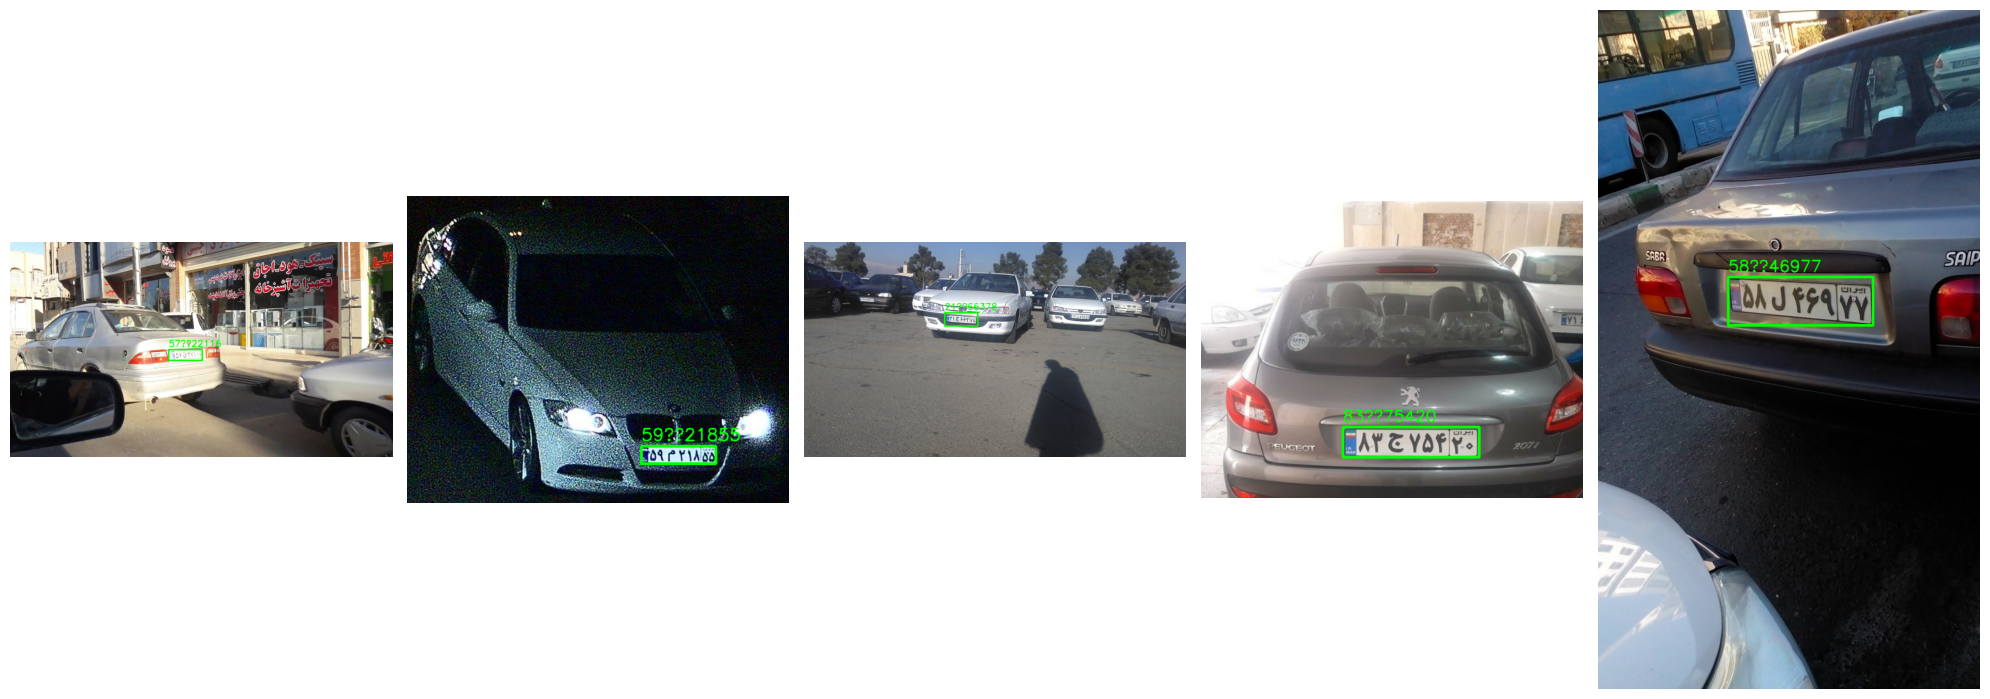

In [55]:
class E2E_LPDR:
    def __init__(self, yolo_model_path, cnn_model_path, device='cpu'):
        self.yolo_model = YOLO(yolo_model_path)
        self.cnn_model = FCNPLPRModel().to(device)

        state_dict = torch.load(cnn_model_path, map_location=device)
        self.cnn_model.load_state_dict(state_dict)
        self.cnn_model.eval()
        self.device = device

        self.transform = transforms.Compose([
            transforms.Resize((64, 128)),
            transforms.ToTensor()
        ])

    def decode_predictions(self, digit_outputs, letter_output):
      digit_preds = torch.argmax(digit_outputs, dim=2).cpu().numpy()
      letter_preds = torch.argmax(letter_output, dim=1).cpu().numpy()

      labels = []
      for idx in range(digit_preds.shape[0]):
          digits = ''.join([digit_vocabulary[i] for i in digit_preds[idx]])

          letter_idx = int(letter_preds[idx])
          if letter_idx < 0 or letter_idx >= len(persian_letters):
              raw_letter = '?'
          else:
              raw_letter = persian_letters[letter_idx]
          label = f"{digits[:2]}{raw_letter}{digits[2:]}"
          labels.append(label)
      return labels


    def process_image(self, img_path):
        img = cv2.imread(str(img_path))
        if img is None:
            raise ValueError(f"Unable to read image: {img_path}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        results = self.yolo_model(img_rgb)
        if not results or not results[0].boxes:
            return []

        boxes = results[0].boxes.xyxy.cpu().numpy()

        predictions = []
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            x1, y1 = max(x1, 0), max(y1, 0)
            plate_img = Image.fromarray(img_rgb[y1:y2, x1:x2])

            plate_tensor = self.transform(plate_img).unsqueeze(0).to(self.device)
            with torch.no_grad():
                digit_logits, letter_logits = self.cnn_model(plate_tensor)

            label = self.decode_predictions(digit_logits, letter_logits)[0]
            predictions.append({
                'bbox': (x1, y1, x2, y2),
                'label': label
            })
        return predictions

def calculate_metrics(e2e_model, max_samples=5):
    test_images = list(Path(TEST_IMAGE_DIR).glob("*.jpg"))[:max_samples]
    total = len(test_images)

    if total == 0:
        raise ValueError(f"No test images found in {TEST_IMAGE_DIR}")

    correct = 0
    total_cer = 0.0

    for img_path in tqdm(test_images, desc="Processing Samples"):
        label_path = Path(TEST_LABEL_DIR) / f"{img_path.stem}.txt"

        if not label_path.exists():
            print(f"Label file missing for {img_path.name}")
            continue

        with open(label_path, 'r', encoding='utf-8') as f:
            gt_label = f.read().strip()

        preds = e2e_model.process_image(img_path)
        if not preds:
            total_cer += 1.0
            continue

        pred_label = preds[0]['label']
        correct += int(pred_label == gt_label)

        if len(gt_label) > 0:
            cer = sum(p != g for p, g in zip(pred_label, gt_label)) / len(gt_label)
        else:
            cer = 1.0
        total_cer += cer

    accuracy = correct / total if total > 0 else 0.0
    avg_cer = total_cer / total if total > 0 else 1.0
    return accuracy, avg_cer

def visualize_predictions(e2e_model, num_samples=5):
    test_images = list(Path(TEST_IMAGE_DIR).glob("*.jpg"))[:num_samples]

    plt.figure(figsize=(20, 10))
    for i, img_path in enumerate(test_images):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        preds = e2e_model.process_image(img_path)
        if not preds:
            continue

        pred = preds[0]
        x1, y1, x2, y2 = pred['bbox']

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img_rgb, pred['label'], (x1, max(y1-10, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img_rgb)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    NUM_SAMPLES = 5

    e2e_model = E2E_LPDR(
        yolo_model_path="/content/LPD_best.pt",
        cnn_model_path="/content/PLPR-CNN.pth",
        device='cpu'
    )

    accuracy, cer = calculate_metrics(e2e_model, max_samples=NUM_SAMPLES)
    print(f"\n{'Accuracy:':<15} {accuracy:.4f}")
    print(f"{'CER:':<15} {cer:.4f}\n")

    visualize_predictions(e2e_model, num_samples=NUM_SAMPLES)


In [ ]:
# من سرچ کردم این مشکل کولب برای نشان دادن حروف فارسی را نتونستم حل کنم مدلم درسته